In [1]:
!pip install -U scikit-learn
!pip install -U flaml

import warnings
warnings.filterwarnings("ignore")

     |████████████████████████████████| 23.2 MB 885 kB/s            
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.23.2
    Uninstalling scikit-learn-0.23.2:
      Successfully uninstalled scikit-learn-0.23.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdpbox 0.2.1 requires matplotlib==3.1.1, but you have matplotlib 3.5.0 which is incompatible.
hypertools 0.7.0 requires scikit-learn!=0.22,<0.24,>=0.19.1, but you have scikit-learn 1.0.1 which is incompatible.
     |████████████████████████████████| 137 kB 895 kB/s            
     |████████████████████████████████| 157.5 MB 56 kB/s               
  Attempting uninstall: xgboost
    Found existing installation: xgboost 1.5.1
    Uninstalling xgboost-1.5.1:
      Successfully uninstalled xgboost-1.5.1


In [2]:
"""
The zip code prefix for Brazil is constructed in a way that the first 2 digits define the state and the rest the sub-regions of the state.
I wanted to use the zip code itself but since their isn't a direct relation between the digits and the regions I preferred not to.
Also because the states have various sizes and populations it seemed reasonable to not use it as a feature as well unless there are regulations and laws to prevent
easy transport between states.
Also the city names in this file are sometimes incorrect. We can probably aggregate zipcodes in a specific range and find the most frequent city name for that
zipcode range.
Some of the zip codes were missing which I interpolated their lat and long from the nearest zipcode.
"""

import numpy as np
import pandas as pd
ogd = pd.read_csv("../input/brazilian-ecommerce/olist_geolocation_dataset.csv").drop(['geolocation_city', 'geolocation_state'], axis = 1)
ogd = ogd.groupby('geolocation_zip_code_prefix').mean()
ogd = ogd.reindex(np.arange(ogd.index.min(), ogd.index.max() + 1)).interpolate(method = 'nearest')
ogd

,geolocation_lat,geolocation_lng
geolocation_zip_code_prefix,,
1001,-23.550190,-46.634024
1002,-23.548146,-46.634979
1003,-23.548994,-46.635731
1004,-23.549799,-46.634757
1005,-23.549456,-46.636733
...,...,...
99986,-28.329595,-51.769362
99987,-28.329595,-51.769362
99988,-28.329595,-51.769362


<AxesSubplot:xlabel='geolocation_lng', ylabel='geolocation_lat'>

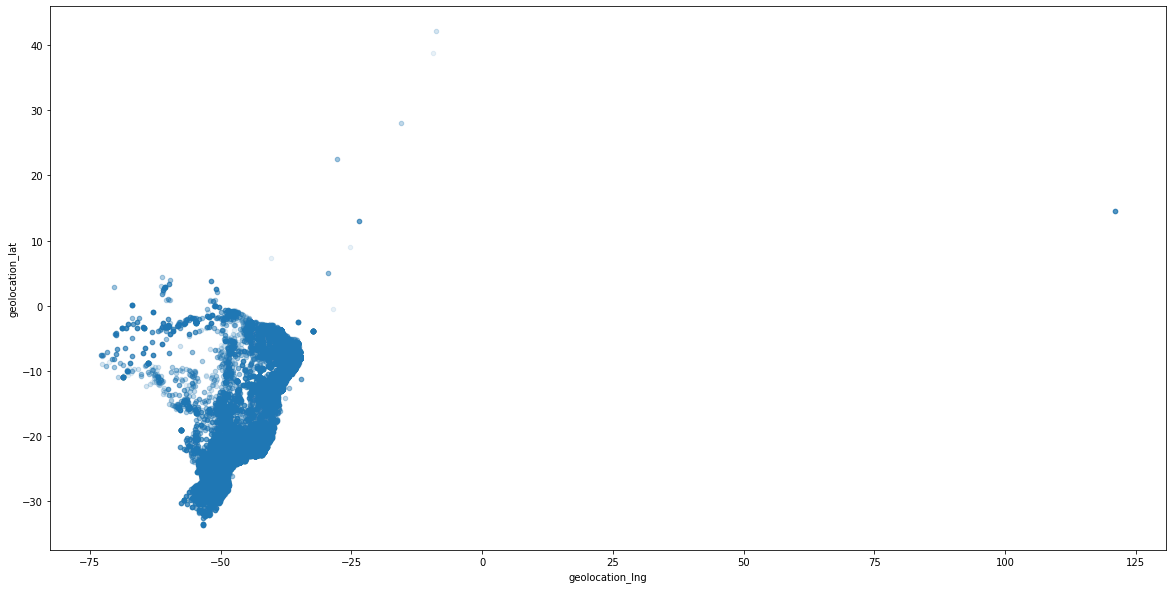

In [3]:
"""
From the plot it seams that either we have zip codes located outside of brazil or their location data is incorrect.
"""

ogd.plot(kind = 'scatter', x = 'geolocation_lng', y = 'geolocation_lat', alpha = 0.1, figsize=(20, 10))

In [4]:
"""
We use the geolocation data to extract the location of each customer.
As mentioned before I don't think the customer's state and city are useful in predicting the delivery delay unless there are specific laws and regulations for
transporting products to and from them.
"""

ocd = pd.read_csv("../input/brazilian-ecommerce/olist_customers_dataset.csv").drop(['customer_unique_id', 'customer_city', 'customer_state'], axis = 1)
ocd = pd.merge(ocd, ogd, left_on = 'customer_zip_code_prefix', right_index = True).drop(['customer_zip_code_prefix'], axis = 1)
ocd

,customer_id,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,-20.498489,-47.396929
650,5dca924cc99eea2dc5ba40d11ec5dd0f,-20.498489,-47.396929
3979,661897d4968f1b59bfff74c7eb2eb4fc,-20.498489,-47.396929
12079,702b62324327ccba20f1be3465426437,-20.498489,-47.396929
12641,bdf997bae7ca819b0415f5174d6b4302,-20.498489,-47.396929
...,...,...,...
99376,0b7a30ba373aeb55cf28add5b5477956,-23.501806,-52.150926
99379,ff6b440b2465bfaef05c675efb48cd15,-28.527590,-54.145960
99382,3f7029d9b98a47370cd5f3a97adcbccd,-23.588483,-46.737908
99406,d9110683c7a282144e9fc97660026a28,-16.822735,-49.248175


<AxesSubplot:xlabel='geolocation_lng', ylabel='geolocation_lat'>

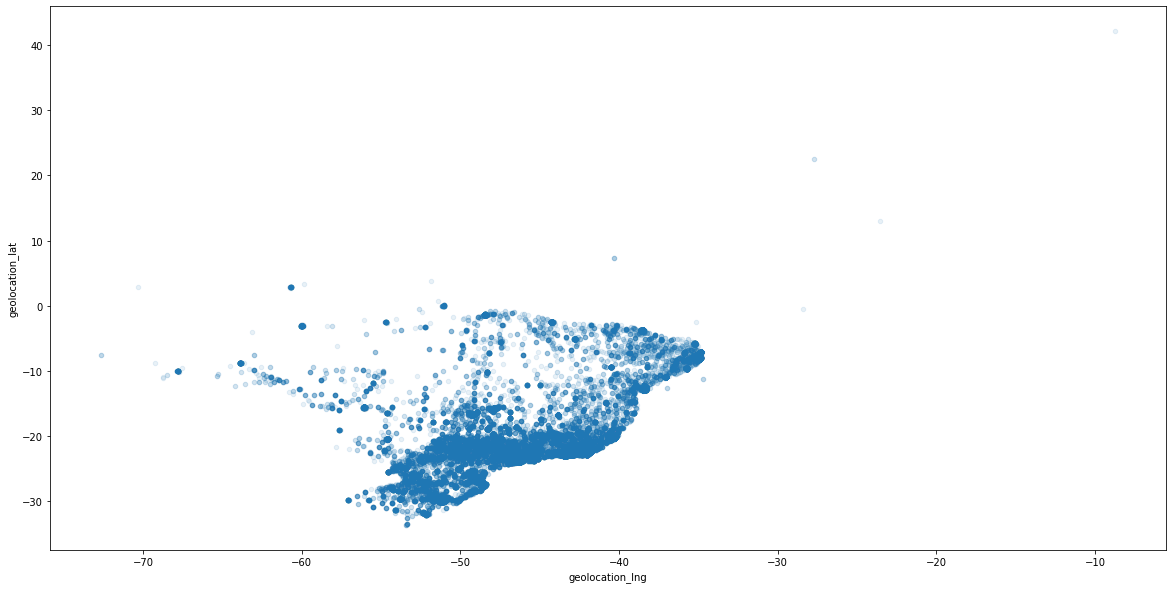

In [5]:
"""
Most of the customers are located in the east and south of Brazil, although there are a few locations outside of brazil which maybe are incorrect.
"""

ocd.plot(kind = 'scatter', x = 'geolocation_lng', y = 'geolocation_lat', alpha = 0.1, figsize=(20, 10))

In [6]:
"""
We use the geolocation data to extract the location of each seller.
As mentioned before I don't think the seller's state and city are useful in predicting the delivery delay unless there are specific laws and regulations for
transporting products to and from them.
"""

osd = pd.read_csv("../input/brazilian-ecommerce/olist_sellers_dataset.csv").drop(['seller_city', 'seller_state'], axis = 1)
osd = pd.merge(osd, ogd, left_on = 'seller_zip_code_prefix', right_index = True).drop(['seller_zip_code_prefix'], axis = 1)
osd

,seller_id,geolocation_lat,geolocation_lng
0,3442f8959a84dea7ee197c632cb2df15,-22.893848,-47.061337
1810,e0eabded302882513ced4ea3eb0c7059,-22.893848,-47.061337
1,d1b65fc7debc3361ea86b5f14c68d2e2,-22.383437,-46.947927
2,ce3ad9de960102d0677a81f5d0bb7b2d,-22.909572,-43.177703
1226,1d2732ef8321502ee8488e8bed1ab8cd,-22.909572,-43.177703
...,...,...,...
3089,f1fdf2d13186575751aa25876536d85c,-23.530647,-46.736453
3090,98dddbc4601dd4443ca174359b237166,-23.448041,-51.869960
3092,74871d19219c7d518d0090283e03c137,-23.657851,-46.676925
3093,e603cf3fec55f8697c9059638d6c8eb5,-31.751072,-52.323202


<AxesSubplot:xlabel='geolocation_lng', ylabel='geolocation_lat'>

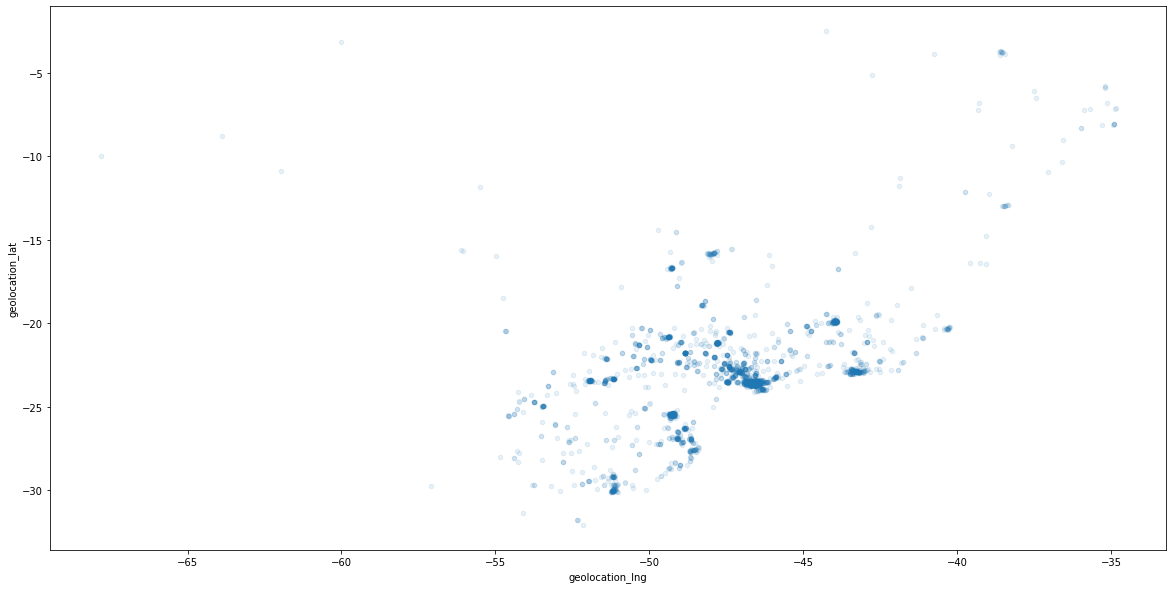

In [7]:
"""
The location of sellers inside Brazil.
"""

osd.plot(kind = 'scatter', x = 'geolocation_lng', y = 'geolocation_lat', alpha = 0.1, figsize=(20, 10))

In [8]:
"""
Features such as product name and description length should not affect the delivery time although it probably has an affect on the probablity of customers buying
them.
Some product categories seem to be the same or very similar which can be corrected.
"""

opd = pd.read_csv("../input/brazilian-ecommerce/olist_products_dataset.csv").drop(['product_name_lenght', 'product_description_lenght', 'product_photos_qty'],
                                                                                  axis = 1)
opd

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,700.0,31.0,13.0,20.0


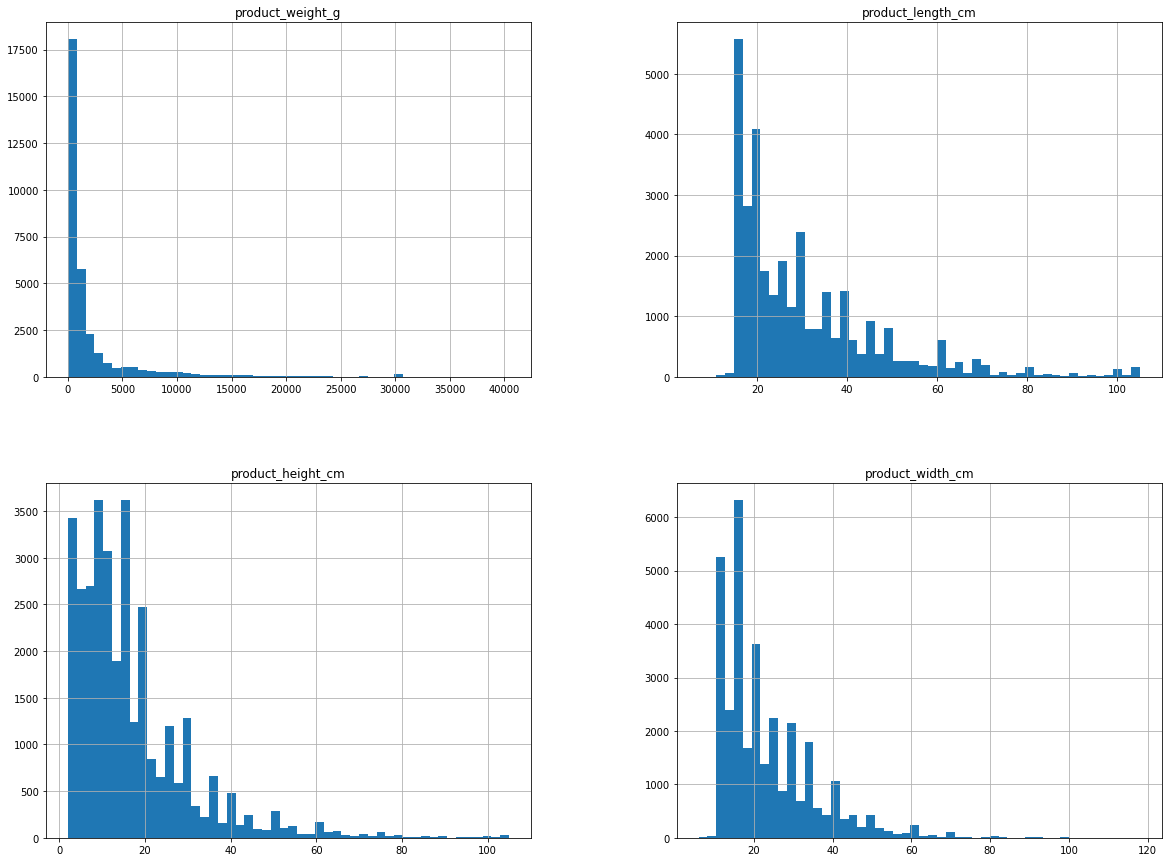

In [9]:
"""
Histogram of the distribution of product weight, length, height and width.
"""

%matplotlib inline
import matplotlib.pyplot as plt

opd.hist(bins = 50, figsize = (20, 15))
plt.show()

In [10]:
"""
Here I load the relation among an order and the user ordering it to use it to predict the distance between a customer and a seller.
"""

ood = pd.read_csv("../input/brazilian-ecommerce/olist_orders_dataset.csv").dropna()
ood = ood[ood['order_status'] == 'delivered']
ood = ood.drop(['order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date'], axis = 1)
ood

,order_id,customer_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c
...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1


In [11]:
"""
Loading the order and its correspondant product data.
"""

ooid = pd.read_csv("../input/brazilian-ecommerce/olist_order_items_dataset.csv").drop(['order_item_id', 'shipping_limit_date'], axis = 1)
ooid

,order_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14
...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,55.99,8.72


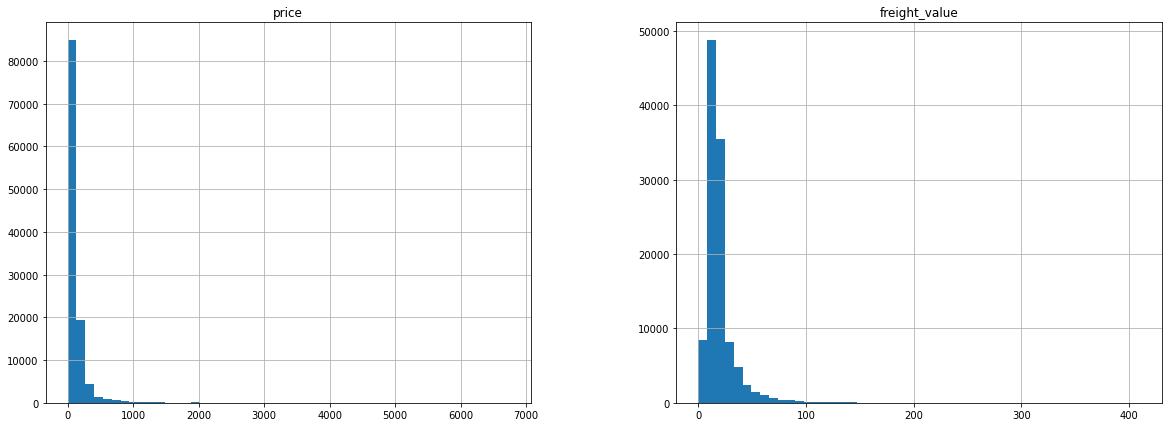

In [12]:
"""
Histogram of an ordered product's price and freight value.
"""

ooid[['price', 'freight_value']].hist(bins = 50, figsize = (20, 7))
plt.show()

In [13]:
"""
Extracting an order's product, customer and seller data.
"""

ooid = pd.merge(ooid, ood, left_on = 'order_id', right_on = 'order_id')
ooid = pd.merge(ooid, opd, left_on = 'product_id', right_on = 'product_id', how = 'left')
ooid = pd.merge(ooid, osd, left_on = 'seller_id', right_on = 'seller_id', how = 'left')
ooid = pd.merge(ooid, ocd, left_on = 'customer_id', right_on = 'customer_id', how = 'left', suffixes = ('_seller', '_customer'))
ooid = ooid.drop(columns=['product_id', 'seller_id', 'customer_id'])
ooid

,order_id,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_lat_seller,geolocation_lng_seller,geolocation_lat_customer,geolocation_lng_customer
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,cool_stuff,650.0,28.0,9.0,14.0,-22.496953,-44.127492,-21.762775,-41.309633
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,pet_shop,30000.0,50.0,30.0,40.0,-23.565096,-46.518565,-20.220527,-50.903424
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,moveis_decoracao,3050.0,33.0,13.0,33.0,-22.262584,-46.171124,-19.870305,-44.593326
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,perfumaria,200.0,16.0,10.0,15.0,-20.553624,-47.387359,-23.089925,-46.611654
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,ferramentas_jardim,3750.0,35.0,40.0,30.0,-22.929384,-53.135873,-23.243402,-46.827614
...,...,...,...,...,...,...,...,...,...,...,...,...
110168,fffc94f6ce00a00581880bf54a75a037,299.99,43.41,utilidades_domesticas,10150.0,89.0,15.0,40.0,-26.912574,-48.673980,-2.497993,-44.297761
110169,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,informatica_acessorios,8950.0,45.0,26.0,38.0,-23.535864,-46.642819,-25.566904,-49.309115
110170,fffce4705a9662cd70adb13d4a31832d,99.90,16.95,esporte_lazer,967.0,21.0,24.0,19.0,-25.469955,-49.289821,-23.597794,-46.643923
110171,fffe18544ffabc95dfada21779c9644f,55.99,8.72,informatica_acessorios,100.0,20.0,20.0,20.0,-23.635530,-46.694031,-23.040252,-46.979782


In [14]:
"""
Measuring the geodisc distance between an order's seller and customer. Also extracting the max measurement of a product and its volume.
"""

from geopy import distance
ooid['distance'] = ooid.apply(lambda x: distance.distance((x['geolocation_lat_seller'], x['geolocation_lng_seller']),
                                                          (x['geolocation_lat_customer'], x['geolocation_lng_customer'])).km, axis=1)
ooid = ooid.drop(['geolocation_lat_seller', 'geolocation_lng_seller', 'geolocation_lat_customer', 'geolocation_lng_customer'], axis = 1)
ooid['product_max_cm'] = ooid[['product_length_cm', 'product_height_cm', 'product_width_cm']].max(axis = 1)
ooid['product_volume_cm'] = ooid['product_length_cm'] * ooid['product_height_cm'] * ooid['product_width_cm']
ooid = ooid.drop(['product_length_cm', 'product_height_cm', 'product_width_cm'], axis = 1)
ooid = ooid.fillna({'product_category_name':'other'})
ooid

,order_id,price,freight_value,product_category_name,product_weight_g,distance,product_max_cm,product_volume_cm
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,cool_stuff,650.0,301.858959,28.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,pet_shop,30000.0,585.131104,50.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,moveis_decoracao,3050.0,311.506212,33.0,14157.0
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,perfumaria,200.0,292.064162,16.0,2400.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,ferramentas_jardim,3750.0,647.209811,40.0,42000.0
...,...,...,...,...,...,...,...,...
110168,fffc94f6ce00a00581880bf54a75a037,299.99,43.41,utilidades_domesticas,10150.0,2741.786140,89.0,53400.0
110169,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,informatica_acessorios,8950.0,351.523090,45.0,44460.0
110170,fffce4705a9662cd70adb13d4a31832d,99.90,16.95,esporte_lazer,967.0,338.924030,24.0,9576.0
110171,fffe18544ffabc95dfada21779c9644f,55.99,8.72,informatica_acessorios,100.0,72.112500,20.0,8000.0


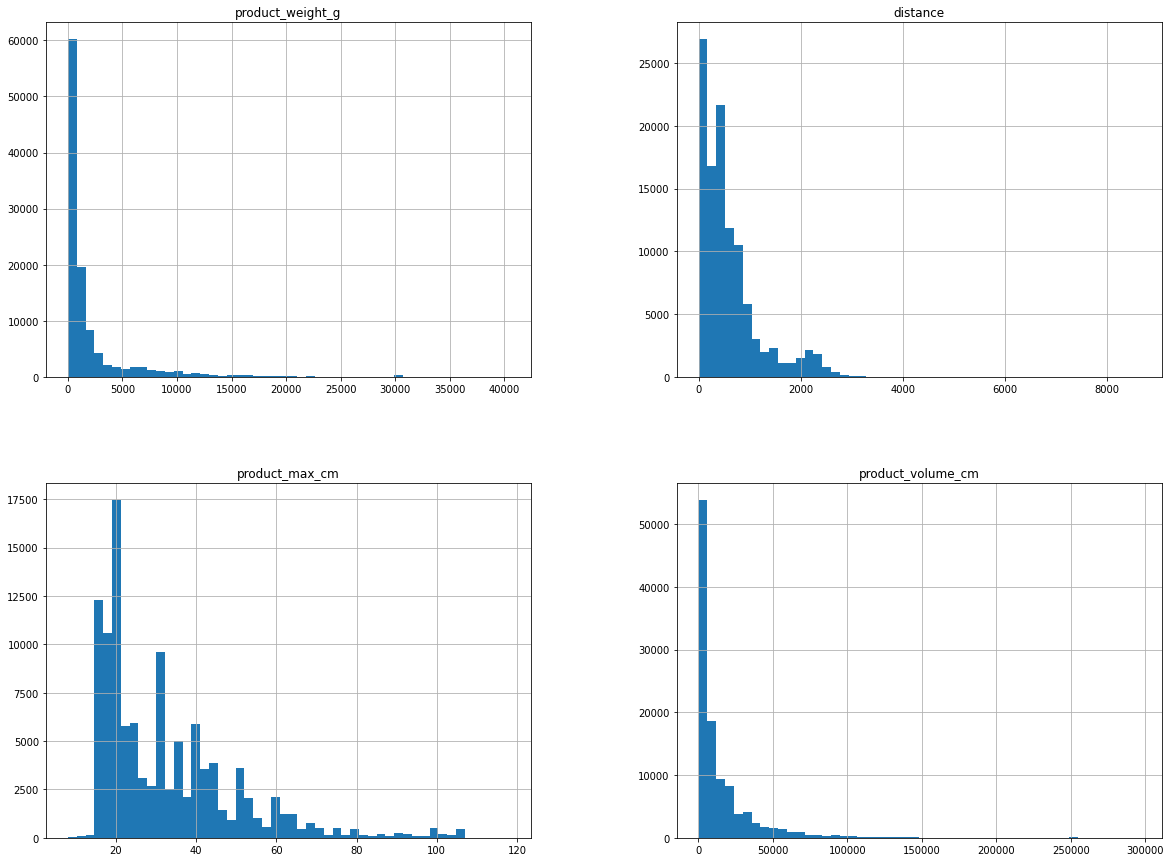

In [15]:
"""
Histogram of ordered products weight, distance, max measurement and volume.
"""

ooid[['product_weight_g', 'distance', 'product_max_cm', 'product_volume_cm']].hist(bins = 50, figsize = (20, 15))
plt.show()

In [16]:
"""
Aggregating product data based on the order and extracting features such as the number of items in the order and the max and sum of other features extracted
previously related to an item. Also aggregating the order's items' categories into a list.
"""

ooid = ooid.groupby('order_id').agg({'price': ['count', 'max', 'sum'], 'freight_value': ['max', 'sum'], 'product_category_name': lambda x: list(x.unique()),
                                     'product_weight_g': ['max', 'sum'], 'distance': ['max', 'sum'], 'product_max_cm': ['max', 'sum'],
                                     'product_volume_cm': ['max', 'sum']})
ooid = ooid.dropna();
ooid.columns = ['item_count', 'price_max', 'price_sum', 'freight_value_max', 'freight_value_sum', 'product_category_names', 'product_weight_g_max',
                'product_weight_g_sum', 'distance_max', 'distance_sum', 'product_max_cm_max', 'product_max_cm_sum', 'product_volume_cm_max', 'product_volume_cm_sum']
ooid

,item_count,price_max,price_sum,freight_value_max,freight_value_sum,product_category_names,product_weight_g_max,product_weight_g_sum,distance_max,distance_sum,product_max_cm_max,product_max_cm_sum,product_volume_cm_max,product_volume_cm_sum
order_id,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,1,58.90,58.90,13.29,13.29,[cool_stuff],650.0,650.0,301.858959,301.858959,28.0,28.0,3528.0,3528.0
00018f77f2f0320c557190d7a144bdd3,1,239.90,239.90,19.93,19.93,[pet_shop],30000.0,30000.0,585.131104,585.131104,50.0,50.0,60000.0,60000.0
000229ec398224ef6ca0657da4fc703e,1,199.00,199.00,17.87,17.87,[moveis_decoracao],3050.0,3050.0,311.506212,311.506212,33.0,33.0,14157.0,14157.0
00024acbcdf0a6daa1e931b038114c75,1,12.99,12.99,12.79,12.79,[perfumaria],200.0,200.0,292.064162,292.064162,16.0,16.0,2400.0,2400.0
00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,199.90,18.14,18.14,[ferramentas_jardim],3750.0,3750.0,647.209811,647.209811,40.0,40.0,42000.0,42000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc94f6ce00a00581880bf54a75a037,1,299.99,299.99,43.41,43.41,[utilidades_domesticas],10150.0,10150.0,2741.786140,2741.786140,89.0,89.0,53400.0,53400.0
fffcd46ef2263f404302a634eb57f7eb,1,350.00,350.00,36.53,36.53,[informatica_acessorios],8950.0,8950.0,351.523090,351.523090,45.0,45.0,44460.0,44460.0
fffce4705a9662cd70adb13d4a31832d,1,99.90,99.90,16.95,16.95,[esporte_lazer],967.0,967.0,338.924030,338.924030,24.0,24.0,9576.0,9576.0


In [17]:
"""
Using a MultiLabelBinarizer to extract a list of boolean tags from the order's list of categories.
"""

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
ooid = pd.concat([ooid, pd.DataFrame(mlb.fit_transform(ooid['product_category_names']), columns = mlb.classes_, index = ooid.index)], axis = 1)
ooid = ooid.drop(['product_category_names', 'other'], axis = 1)
ooid

,item_count,price_max,price_sum,freight_value_max,freight_value_sum,product_weight_g_max,product_weight_g_sum,distance_max,distance_sum,product_max_cm_max,...,pet_shop,portateis_casa_forno_e_cafe,portateis_cozinha_e_preparadores_de_alimentos,relogios_presentes,seguros_e_servicos,sinalizacao_e_seguranca,tablets_impressao_imagem,telefonia,telefonia_fixa,utilidades_domesticas
order_id,,,,,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,1,58.90,58.90,13.29,13.29,650.0,650.0,301.858959,301.858959,28.0,...,0,0,0,0,0,0,0,0,0,0
00018f77f2f0320c557190d7a144bdd3,1,239.90,239.90,19.93,19.93,30000.0,30000.0,585.131104,585.131104,50.0,...,1,0,0,0,0,0,0,0,0,0
000229ec398224ef6ca0657da4fc703e,1,199.00,199.00,17.87,17.87,3050.0,3050.0,311.506212,311.506212,33.0,...,0,0,0,0,0,0,0,0,0,0
00024acbcdf0a6daa1e931b038114c75,1,12.99,12.99,12.79,12.79,200.0,200.0,292.064162,292.064162,16.0,...,0,0,0,0,0,0,0,0,0,0
00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,199.90,18.14,18.14,3750.0,3750.0,647.209811,647.209811,40.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc94f6ce00a00581880bf54a75a037,1,299.99,299.99,43.41,43.41,10150.0,10150.0,2741.786140,2741.786140,89.0,...,0,0,0,0,0,0,0,0,0,1
fffcd46ef2263f404302a634eb57f7eb,1,350.00,350.00,36.53,36.53,8950.0,8950.0,351.523090,351.523090,45.0,...,0,0,0,0,0,0,0,0,0,0
fffce4705a9662cd70adb13d4a31832d,1,99.90,99.90,16.95,16.95,967.0,967.0,338.924030,338.924030,24.0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
"""
Reading the amount of payment done for each order.
"""

oopd = pd.read_csv("../input/brazilian-ecommerce/olist_order_payments_dataset.csv").drop(['payment_sequential', 'payment_type', 'payment_installments'], axis = 1)
oopd

,order_id,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,65.71
3,ba78997921bbcdc1373bb41e913ab953,107.78
4,42fdf880ba16b47b59251dd489d4441a,128.45
...,...,...
103881,0406037ad97740d563a178ecc7a2075c,363.31
103882,7b905861d7c825891d6347454ea7863f,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,47.77
103884,b8b61059626efa996a60be9bb9320e10,369.54


In [19]:
"""
Reading order data such as when it was purchased and when it was delivered and the various events inbetween.
Dropped rows with no delivery date, a few others also which didn't have approval date.
"""

ood = pd.read_csv("../input/brazilian-ecommerce/olist_orders_dataset.csv", parse_dates = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']).dropna()
ood = ood[ood['order_status'] == 'delivered']
ood = ood.drop(['customer_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date'], axis = 1)
ood

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15


In [20]:
"""
Extracting the delay between ordering a purchase and recieving it in days. Also measuring the root mean square error of the current estimate of delivery date.
"""

from math import sqrt
from sklearn.metrics import mean_squared_error

ood['order_delivered_customer_date_delay'] = (ood['order_delivered_customer_date'] - ood['order_purchase_timestamp']).dt.total_seconds() / 86400
ood['order_estimated_delivery_date_delay'] = (ood['order_estimated_delivery_date'] - ood['order_purchase_timestamp']).dt.total_seconds() / 86400
print('Current RMSE of the estimated delivery date: ' + str(sqrt(mean_squared_error(ood['order_delivered_customer_date_delay'], ood['order_estimated_delivery_date_delay']))))

Current RMSE of the estimated delivery date: 15.120599183092542


In [21]:
"""
Extracting the year, month, day of month, day of week and hour of a purchase.
"""

ood['order_purchase_year'] = ood['order_purchase_timestamp'].dt.year
ood['order_purchase_month'] = ood['order_purchase_timestamp'].dt.month
ood['order_purchase_day'] = ood['order_purchase_timestamp'].dt.day
ood['order_purchase_dayofweek'] = ood['order_purchase_timestamp'].dt.dayofweek
ood['order_purchase_hour'] = ood['order_purchase_timestamp'].dt.hour
ood = ood.drop(['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_estimated_delivery_date_delay'], axis = 1)
ood

,order_id,order_delivered_customer_date_delay,order_purchase_year,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,2017,10,2,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,2018,7,24,1,20
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,2018,8,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,2017,11,18,5,19
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,2018,2,13,1,21
...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,8.218009,2017,3,9,3,9
99437,63943bddc261676b46f01ca7ac2f7bd8,22.193727,2018,2,6,1,12
99438,83c1379a015df1e13d02aae0204711ab,24.859421,2017,8,27,6,14
99439,11c177c8e97725db2631073c19f07b62,17.086424,2018,1,8,0,21


In [22]:
"""
Joining all order features together.
"""

ood = pd.merge(ood, oopd, left_on = 'order_id', right_on = 'order_id')
ood = pd.merge(ood, ooid, left_on = 'order_id', right_index = True)
ood = ood.set_index('order_id')
ood

,order_delivered_customer_date_delay,order_purchase_year,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour,payment_value,item_count,price_max,price_sum,...,pet_shop,portateis_casa_forno_e_cafe,portateis_cozinha_e_preparadores_de_alimentos,relogios_presentes,seguros_e_servicos,sinalizacao_e_seguranca,tablets_impressao_imagem,telefonia,telefonia_fixa,utilidades_domesticas
order_id,,,,,,,,,,,,,,,,,,,,,
e481f51cbdc54678b7cc49136f2d6af7,8.436574,2017,10,2,0,10,18.12,1,29.99,29.99,...,0,0,0,0,0,0,0,0,0,1
e481f51cbdc54678b7cc49136f2d6af7,8.436574,2017,10,2,0,10,2.00,1,29.99,29.99,...,0,0,0,0,0,0,0,0,0,1
e481f51cbdc54678b7cc49136f2d6af7,8.436574,2017,10,2,0,10,18.59,1,29.99,29.99,...,0,0,0,0,0,0,0,0,0,1
53cdb2fc8bc7dce0b6741e2150273451,13.782037,2018,7,24,1,20,141.46,1,118.70,118.70,...,0,0,0,0,0,0,0,0,0,0
47770eb9100c2d0c44946d9cf07ec65d,9.394213,2018,8,8,2,8,179.12,1,159.90,159.90,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9c5dedf39a927c1b2549525ed64a053c,8.218009,2017,3,9,3,9,85.08,1,72.00,72.00,...,0,0,0,0,0,0,0,0,0,0
63943bddc261676b46f01ca7ac2f7bd8,22.193727,2018,2,6,1,12,195.00,1,174.90,174.90,...,0,0,0,0,0,0,0,0,0,0
83c1379a015df1e13d02aae0204711ab,24.859421,2017,8,27,6,14,271.01,1,205.99,205.99,...,0,0,0,0,0,0,0,0,0,0


In [23]:
"""
Viewing some statistics on the order features. As it can be seen there are order with more than 200 days delay which are outliers or incorrect data.
"""

ood.describe()

,order_delivered_customer_date_delay,order_purchase_year,order_purchase_month,order_purchase_day,order_purchase_dayofweek,order_purchase_hour,payment_value,item_count,price_max,price_sum,...,pet_shop,portateis_casa_forno_e_cafe,portateis_cozinha_e_preparadores_de_alimentos,relogios_presentes,seguros_e_servicos,sinalizacao_e_seguranca,tablets_impressao_imagem,telefonia,telefonia_fixa,utilidades_domesticas
count,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,...,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000,100715.000000
mean,12.570757,2017.540724,6.031644,15.508147,2.754684,14.784173,153.067120,1.141747,126.045010,137.101475,...,0.017505,0.000735,0.000129,0.056536,0.000020,0.001390,0.000824,0.042228,0.002155,0.060418
std,9.549921,0.503948,3.225483,8.667554,1.965183,5.338525,214.410028,0.535441,191.155628,209.401133,...,0.131143,0.027096,0.011361,0.230955,0.004456,0.037258,0.028696,0.201110,0.046368,0.238261
min,0.533414,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.850000,0.850000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.780799,2017.000000,3.000000,8.000000,1.000000,11.000000,56.780000,1.000000,42.110000,45.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10.231065,2018.000000,6.000000,15.000000,3.000000,15.000000,100.000000,1.000000,79.000000,85.990000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.712888,2018.000000,8.000000,23.000000,4.000000,19.000000,171.300000,1.000000,139.900000,149.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,209.628611,2018.000000,12.000000,31.000000,6.000000,23.000000,13664.080000,21.000000,6735.000000,13440.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
"""
We use sin and cos to map interval features such as hour of day and day of week to values which would better represent their periodic nature.
Also dividing the data into a train and test set and standardizing numerical data such as the weight and length of products.
"""

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numerical_columns = ['order_purchase_year', 'payment_value', 'item_count', 'price_max', 'price_sum', 'freight_value_max', 'freight_value_sum', 'product_weight_g_max', 'product_weight_g_sum', 'distance_max', 'distance_sum', 'product_max_cm_max', 'product_max_cm_sum', 'product_volume_cm_max', 'product_volume_cm_sum']
nominal_columns = ['order_purchase_month', 'order_purchase_day', 'order_purchase_dayofweek', 'order_purchase_hour']

ood_p = ood.drop(['order_delivered_customer_date_delay'], axis = 1)
ood_p['order_purchase_month_sin'] = np.sin(ood_p['order_purchase_month'] / 12 * 2 * np.pi)
ood_p['order_purchase_month_cos'] = np.cos(ood_p['order_purchase_month'] / 12 * 2 * np.pi)
ood_p['order_purchase_day_sin'] = np.sin(ood_p['order_purchase_day'] / 31 * 2 * np.pi)
ood_p['order_purchase_day_cos'] = np.cos(ood_p['order_purchase_day'] / 31 * 2 * np.pi)
ood_p['order_purchase_dayofweek_sin'] = np.sin(ood_p['order_purchase_dayofweek'] / 7 * 2 * np.pi)
ood_p['order_purchase_dayofweek_cos'] = np.cos(ood_p['order_purchase_dayofweek'] / 7 * 2 * np.pi)
ood_p['order_purchase_hour_sin'] = np.sin(ood_p['order_purchase_hour'] / 24 * 2 * np.pi)
ood_p['order_purchase_hour_cos'] = np.cos(ood_p['order_purchase_hour'] / 24 * 2 * np.pi)
ood_p = ood_p.drop(nominal_columns, axis = 1)

train_data, test_data, train_labels, test_labels = train_test_split(ood_p, ood['order_delivered_customer_date_delay'], test_size = 0.2, random_state = 42)

pipeline = ColumnTransformer([
    ("Numerical", StandardScaler(), numerical_columns),
    ], remainder = 'passthrough',)

train_data = pipeline.fit_transform(train_data)
test_data = pipeline.transform(test_data)

In [25]:
"""
Using a set of various models to estimate the delivery delay amount. I have shown various metrics here but the quantile loss or the mean pinball loss might be
better because it is more important for us to deliver a product early rather than late. We can also use an ensemble of the best models.
"""

import time
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_pinball_loss

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import SGDRegressor
from sklearn.svm import LinearSVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost.sklearn import XGBRegressor
from catboost import CatBoostRegressor

models = [['LinearRegression', LinearRegression()],
          ['BayesianRidge', BayesianRidge()],
          ['SGD', SGDRegressor()],
          ['LinearSVR', LinearSVR()],
          ['HistGradientBoosting', HistGradientBoostingRegressor()],
          ['GradientBoosting', GradientBoostingRegressor()],
          ['LGBM', LGBMRegressor()],
          ['XGB', XGBRegressor()],
          ['CatBoost', CatBoostRegressor(logging_level = 'Silent')],]

model_data = []
for name, curr_model in models :
    curr_model_data = {}
    curr_model.random_state = 42
    curr_model_data["Name"] = name
    start = time.time()
    curr_model.fit(train_data, train_labels)
    end = time.time()
    train_pred = curr_model.predict(train_data)
    test_pred = curr_model.predict(test_data)
    curr_model_data["Train_Time"] = end - start
    curr_model_data["Train_MAE"] = mean_absolute_error(train_labels, train_pred)
    curr_model_data["Test_MAE"] = mean_absolute_error(test_labels, test_pred)
    curr_model_data["Train_MSE"] = mean_squared_error(train_labels, train_pred)
    curr_model_data["Test_MSE"] = mean_squared_error(test_labels, test_pred)
    curr_model_data["Train_RMSE"] = sqrt(mean_squared_error(train_labels, train_pred))
    curr_model_data["Test_RMSE"] = sqrt(mean_squared_error(test_labels, test_pred))
    curr_model_data["Train_MAPE"] = mean_absolute_percentage_error(train_labels, train_pred)
    curr_model_data["Test_MAPE"] = mean_absolute_percentage_error(test_labels, test_pred)
    curr_model_data["Train_R2"] = r2_score(train_labels, train_pred)
    curr_model_data["Test_R2"] = r2_score(test_labels, test_pred)
    curr_model_data["Train_Quantile_Loss"] = mean_pinball_loss(train_labels, train_pred, alpha = 0.75)
    curr_model_data["Test_Quantile_Loss"] = mean_pinball_loss(test_labels, test_pred, alpha = 0.75)
    model_data.append(curr_model_data)

model_scores = pd.DataFrame(model_data)
model_scores

,Name,Train_Time,Train_MAE,Test_MAE,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE,Train_R2,Test_R2,Train_Quantile_Loss,Test_Quantile_Loss
0,LinearRegression,0.385544,5.299546,5.169724,71.947158,63.565616,8.482167,7.972805,0.586064,0.587254,0.224786,0.249908,2.649773,2.533164
1,BayesianRidge,0.692289,5.300961,5.169874,71.969256,63.574664,8.483470,7.973372,0.586683,0.587641,0.224548,0.249801,2.650481,2.533275
2,SGD,1.377356,5.300324,5.167914,72.162390,63.693904,8.494845,7.980846,0.590437,0.591759,0.222467,0.248394,2.666939,2.549057
3,LinearSVR,10.179091,5.038124,4.886721,75.988815,66.600721,8.717156,8.160927,0.462306,0.461980,0.181238,0.214093,2.980168,2.852894
4,HistGradientBoosting,3.385561,4.719747,4.740850,59.152259,56.477108,7.691051,7.515125,0.488709,0.500527,0.362648,0.333555,2.358591,2.316144
5,GradientBoosting,41.160432,4.996841,4.909421,65.857757,59.258722,8.115279,7.697969,0.519750,0.523002,0.290398,0.300731,2.498421,2.402163
6,LGBM,1.009051,4.720926,4.739643,59.170338,56.329347,7.692226,7.505288,0.488033,0.500073,0.362453,0.335298,2.360463,2.317593
7,XGB,15.292295,4.339092,4.755195,46.625956,57.580786,6.828320,7.588200,0.447202,0.494325,0.497616,0.320531,2.169983,2.317702
8,CatBoost,11.243343,4.527619,4.695443,52.546704,55.809537,7.248911,7.470578,0.463326,0.489651,0.433821,0.341432,2.263983,2.292098


<AxesSubplot:xlabel='Name'>

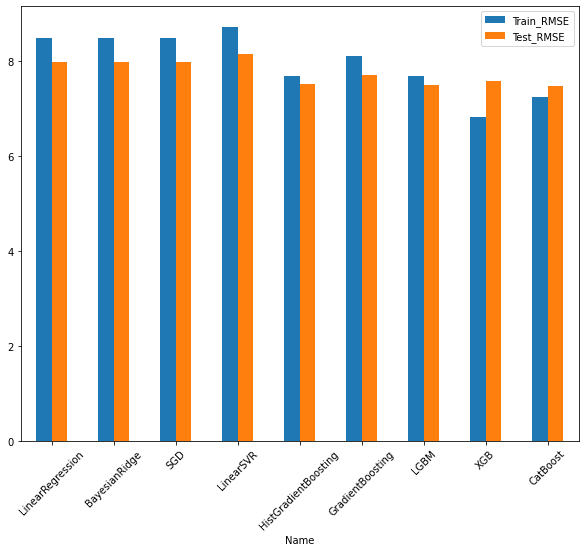

In [26]:
model_scores.plot(x = 'Name', y = ['Train_RMSE', 'Test_RMSE'], kind = 'bar', figsize = (10, 8), rot = 45)

In [27]:
"""
Optimizing the hyperparameters of the model.
"""
from flaml import AutoML

automl = AutoML()
automl_settings = {
    'time_budget': 180,
    'task': 'regression',
    'estimator_list': ['lgbm'],
    'metric': 'rmse',
    'verbose': 0,
}

automl.fit(X_train = train_data, y_train = train_labels, **automl_settings)

print('Best hyperparmeter config:', automl.best_config)

Best hyperparmeter config: {'n_estimators': 141, 'num_leaves': 64, 'min_child_samples': 7, 'learning_rate': 0.04382186684664449, 'log_max_bin': 9, 'colsample_bytree': 0.631750356327906, 'reg_alpha': 0.0009765625, 'reg_lambda': 7.03848186185798, 'FLAML_sample_size': 10000}


In [28]:
print('Optimized model train error: ' + str(np.sqrt(mean_squared_error(automl.predict(train_data), train_labels))))

Optimized model train error: 7.50311066299673


In [29]:
print('Optimized model test error: ' + str(np.sqrt(mean_squared_error(automl.predict(test_data), test_labels))))

Optimized model test error: 7.475551276886482


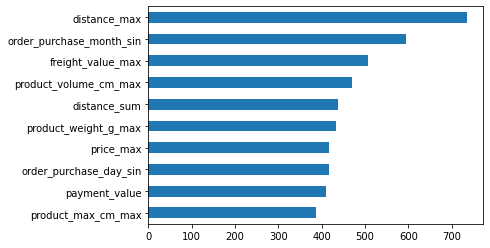

In [30]:
"""
Most important features for the model.
"""

feat_importances = pd.Series(automl.model.estimator.feature_importances_, index = ood_p.columns)
feat_importances.nlargest(10).plot(kind = 'barh').invert_yaxis()